In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt


In [6]:
# Load MNIST
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

# Use only 2000 samples
X_train = X_train[:2000]
y_train = y_train[:2000]

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Flatten
X_train = X_train.reshape(-1, 784)
X_test = X_test.reshape(-1, 784)


In [7]:
def plot_history(history, title):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title + " - Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " - Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()

    plt.show()


In [8]:
def print_accuracies(model, history, name):
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"\n{name}")
    print("-" * 45)
    print(f"Training Accuracy   : {train_acc:.4f}")
    print(f"Validation Accuracy : {val_acc:.4f}")
    print(f"Test Accuracy       : {test_acc:.4f}")


In [9]:
def overfit_model():
    model = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


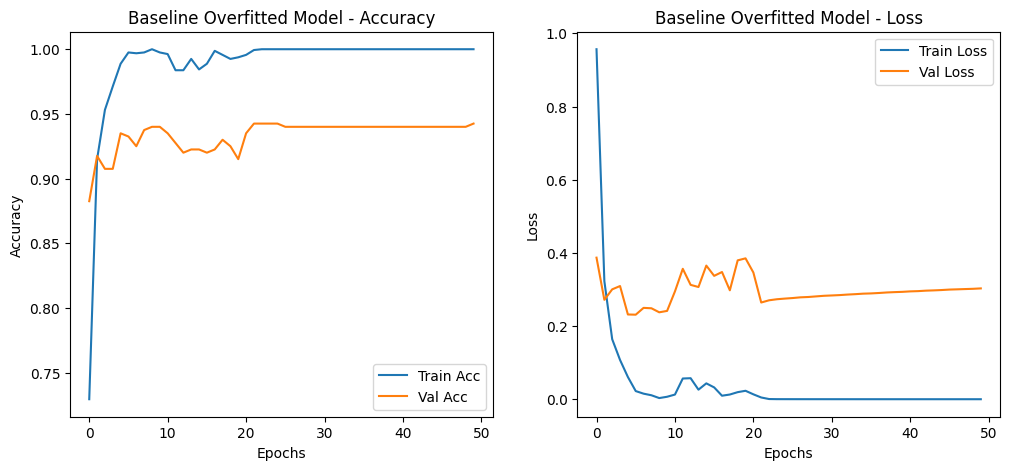


Baseline Overfitted Model
---------------------------------------------
Training Accuracy   : 1.0000
Validation Accuracy : 0.9425
Test Accuracy       : 0.9255


In [10]:
model_overfit = overfit_model()
history_overfit = model_overfit.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

plot_history(history_overfit, "Baseline Overfitted Model")
print_accuracies(model_overfit, history_overfit, "Baseline Overfitted Model")


In [11]:
def batchnorm_model():
    model = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(784,)),
        layers.BatchNormalization(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


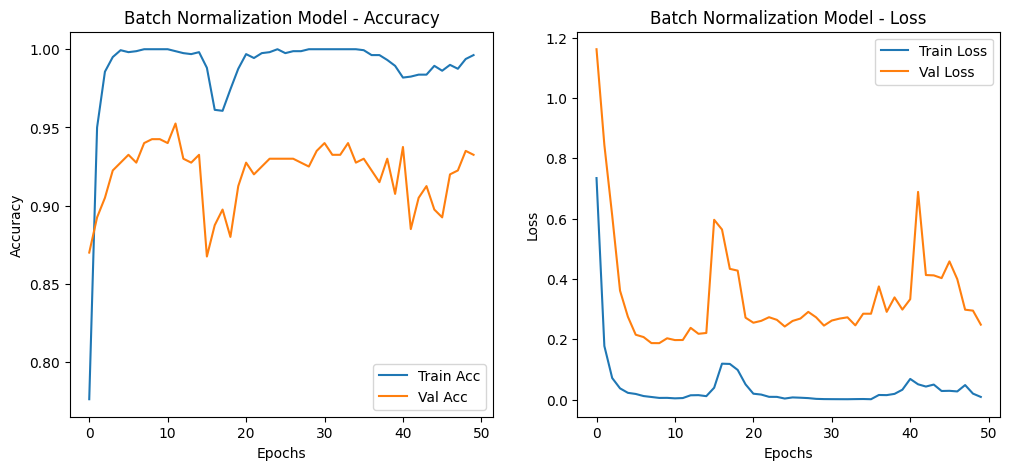


Batch Normalization Model
---------------------------------------------
Training Accuracy   : 0.9962
Validation Accuracy : 0.9325
Test Accuracy       : 0.9162


In [12]:
model_bn = batchnorm_model()
history_bn = model_bn.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

plot_history(history_bn, "Batch Normalization Model")
print_accuracies(model_bn, history_bn, "Batch Normalization Model")


In [13]:
def l2_model():
    model = models.Sequential([
        layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001),
                     input_shape=(784,)),
        layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


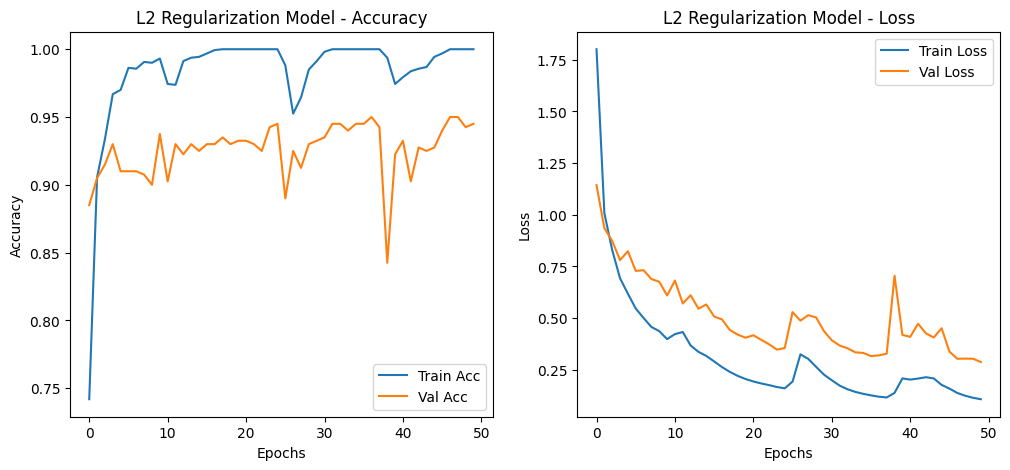


L2 Regularization Model
---------------------------------------------
Training Accuracy   : 1.0000
Validation Accuracy : 0.9450
Test Accuracy       : 0.9254


In [14]:
model_l2 = l2_model()
history_l2 = model_l2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

plot_history(history_l2, "L2 Regularization Model")
print_accuracies(model_l2, history_l2, "L2 Regularization Model")


In [15]:
def dropout_model():
    model = models.Sequential([
        layers.Dense(512, activation='relu', input_shape=(784,)),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


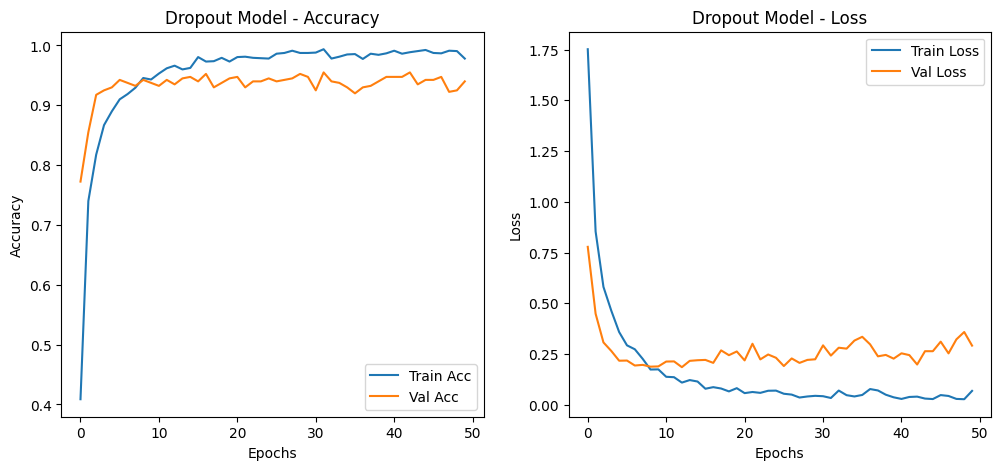


Dropout Model
---------------------------------------------
Training Accuracy   : 0.9781
Validation Accuracy : 0.9400
Test Accuracy       : 0.9178


In [16]:
model_dropout = dropout_model()
history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

plot_history(history_dropout, "Dropout Model")
print_accuracies(model_dropout, history_dropout, "Dropout Model")
